# COMPSCI 714 - Lectutorial 2 - Training and evaluating a DNN with PyTorch

Disclaimer: The code in this notebook is adapted from https://github.com/ageron/handson-mlp (Apache License, Version 2.0, http://www.apache.org/licenses/)

## Coding time 1 - PyTorch basics

In [2]:
import numpy as np
import torch

### Pytorch Tensors

The core data structure used in PyTorch is the **tensor**. They are very similars to arrays and matrices (e.g., NumPy array) and can be used to store data as a multidimentional array with a data type.

The main difference with Numpy arrays is that Pytorch tensors supports two main additional features:
- They can run on GPUs, while NumPy arrays are designed for CPU-based computations only and do not have built-in GPU support.
- They support auto-differentiation (i.e., PyTorch captures information about operations applied to the tensor and can use it to calculate gradients automatically with *Autograd*).

In [3]:
X = torch.tensor([[1.0, 4.0, 7.0, 9.0], [2.0, 3.0, 6.0, 8.0]])
X

tensor([[1., 4., 7., 9.],
        [2., 3., 6., 8.]])

Display the shape and data type of the tensor `X` (similar than with a NumPy array with the `shape` and `dtype` fields).

In [4]:
X.shape

torch.Size([2, 4])

In [5]:
X.dtype

torch.float32

Try to index the tensor, e.g., display
- the third value of the first row, and
- the last values of the both rows.

In [6]:
X[0,2]

tensor(7.)

In [7]:
X[:,-1]

tensor([9., 8.])

You can perform operations on tensors very similarly as on NumPy arrays. \
Try to run the few following operations and comment on what they do.

In [7]:
8 * (X + 4)

tensor([[ 40.,  64.,  88., 104.],
        [ 48.,  56.,  80.,  96.]])

In [8]:
X.exp()

tensor([[2.7183e+00, 5.4598e+01, 1.0966e+03, 8.1031e+03],
        [7.3891e+00, 2.0086e+01, 4.0343e+02, 2.9810e+03]])

In [9]:
X.mean()

tensor(5.)

In [11]:
X.mean(axis = 0)

tensor([1.5000, 3.5000, 6.5000, 8.5000])

In [12]:
X.max(axis=0)

torch.return_types.max(
values=tensor([2., 4., 7., 9.]),
indices=tensor([1, 0, 0, 0]))

In [13]:
X @ X.T

tensor([[147., 128.],
        [128., 113.]])

You can convert a tensor to a NumPy array, and vice versa.

In [14]:
X.numpy()

array([[1., 4., 7., 9.],
       [2., 3., 6., 8.]], dtype=float32)

In [18]:
torch.tensor(np.array([[1., 4., 7.], [2., 3., 6.]]), dtype = torch.float32).dtype

torch.float32

Or if you want the data precision of the tensor to be converted to 32-bits:

In [19]:
torch.FloatTensor(np.array([[1., 4., 7.], [2., 3., 6]]))

tensor([[1., 4., 7.],
        [2., 3., 6.]])

### Autograd

PyTorch comes with an implementation of auto-differentiation called *Autograd* (Automated gradients). It can be used to compute the derivative of a function, i.e., its gradient. For a enable *Autograd* to be performed on a tensor, you have to set `requires_grad=True` when creating it.

In [20]:
x = torch.tensor(5.0, requires_grad=True)
x

tensor(5., requires_grad=True)

Let's then create a function performing a computation on tensor `x`.

In [21]:
f = x ** 2
f

tensor(25., grad_fn=<PowBackward0>)

Notice that `f` is also a tensor, carrying the fucntion `grad_fn=<PowBackward0>`. It is the function that would be used if you ecide to backpropagate the gradients through the operation performed by `f` (** is the power operator, hence the name `PowBackward0`).

Let's now backpropagate the gradient.

In [22]:
f.backward()

This backpropagates the gradient from `f` to `x`. This is quite straighforward here, but imagine this applied to a full DNN. The gradient would be backpropagated from the outputs to the inputs, through all the `grad_fn` registered during the forward pass.

Let's now have a look at the gradient value associated with `x`, i.e., the value of the derivative of `f` with respect to `x` Does this value makes sense to you?

In [23]:
x.grad

tensor(10.)

### Hardware acceleration

CUDA-enabled NVIDIA GPU and Apple's MPS are directly supported by PyTorch. You can check for them and else fall back on the CPU:

In [62]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [25]:
device

'cuda'

To perform computations with tensors on a GPU, you need to move your tensors to the GPU device:

In [26]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]])
M = M.to(device)

In [27]:
M.device

device(type='cuda', index=0)

In [28]:
M = torch.tensor([[2., 4., 6.], [8., 6., 4.]], device=device)

In [29]:
M.device

device(type='cuda', index=0)

In [30]:
M = torch.rand((1000, 1000))

In [31]:
%timeit M @ M.T

16.5 ms ± 2.97 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [32]:
M = torch.rand((1000, 1000), device=device)

In [34]:
%timeit M @ M.T

563 µs ± 12.7 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


How much faster is this matrix multiplication being computed on GPU?

In [ ]:
# TODO

## Coding time 2: Training a simple DNN for regression

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [4]:
# %pip install torchmetrics
import torchmetrics

### Regression

#### Loading the dataset

Let's first load the california housing dataset from Scikit-Learn.

In [9]:
housing_dataset = fetch_california_housing()

Run the next cell to see what data format is the dataset loaded as.

In [13]:
type(housing_dataset)

sklearn.utils._bunch.Bunch

What is the shape of the data?

In [15]:
housing_dataset

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [17]:
housing_dataset.data.shape

(20640, 8)

First, let's divide it into train/validation/test sets with a 60%/20%/20% ratio.

The next line of code splits the data into train/test sets with a 80%/20% ratio. Extend the code to create the validation set as well.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(housing_dataset.data, housing_dataset.target, test_size=0.2)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.25)

In [21]:
min(y_train)

np.float64(0.14999)

How many samples are there in each set?

What is the type of data structure used to store the sets?

In [27]:
print(X_train.shape[0])
print(X_valid.shape[0])
print(X_test.shape[0])

12384
4128
4128


In [31]:
type(X_test)

numpy.ndarray

As we saw before, PyTorch works with tensors. We need to convert the sets and associated targets to tensors.

In [35]:
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train)
y_valid = torch.FloatTensor(y_valid)
y_test = torch.FloatTensor(y_test)

Next, we will do a quick touch of pre-processing by standardising the values of the attributes. We can do it manually this time, by computing the mean and standard deviation for each attribute.

In [37]:
means = X_train.mean(axis=0, keepdims=True)
stds = X_train.std(axis=0, keepdims=True)
X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_test - means) / stds

What are the shapes of `y_train`, `y_valid` and `y_test`?

In [39]:
y_train.shape

torch.Size([12384])

These are 1D tensors, however, PyTorch models generally expects 2D tensors. 1D tensors might be treated differently from a 2D tensors when performing some operations like matrix multiplication.

Therefore, we need to reshape our target tensors to 2D tensors.

In [41]:
y_train = y_train.reshape(-1, 1)
y_valid = y_valid.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

In [43]:
print(y_train.shape)
print(y_valid.shape)
print(y_test.shape)

torch.Size([12384, 1])
torch.Size([4128, 1])
torch.Size([4128, 1])


#### Declaring the model

Next, let's create our first multilayer neural network! The easiest way is to use the PyTorch `nn.Sequential` module. It allows to create a stack of layers.

The following cell defines a neural network with:
- 2 hidden layers, the first one with 50 neurons and the second one with 40 neurons. Both use the ReLU activation function (we will cover it next week).
- 1 output layer.

Note that we declared all the layers as full-connected layers, also called dense layers, with the `nn.Linear` module. To create a `Linear` layer, we need to pass the shape of the parameter matrix as argument. This shape corresponds to the layers's $number\ of\ inputs \times number\ of\ outputs$.

What should be the values of assigned to the variables `n_attributes` and `n_outputs`?

In [45]:
X_train.shape[1]

8

In [47]:
n_attributes = X_train.shape[1]
n_outputs = 1
model = nn.Sequential(
nn.Linear(n_attributes, 50),
nn.ReLU(),
nn.Linear(50, 40),
nn.ReLU(),
nn.Linear(40, n_outputs)
)

We can wrap this in a function as we might need to reset our model later on.

In [49]:
def set_model():
  n_attributes = X_train.shape[1]
  n_outputs = 1
  model = nn.Sequential(
  nn.Linear(n_attributes, 50),
  nn.ReLU(),
  nn.Linear(50, 40),
  nn.ReLU(),
  nn.Linear(40, n_outputs)
  )
  return model

#### Training the model

Next, we need to set:
- the optimiser we want to use to train the model (let's use SGD),
- the loss function (let's use MSE),
- the learning rate (let's start at 0.1),
- the number of epochs (let's set it to 20).

In [51]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
n_epochs = 20

Finally, let's define a simple training loop.

If you have a look at hos to do this with TensorFlow, you will see that the module you can use to create a model has already a pre-defined method to train (*fit*) the model. With PyTorch, you have to create the training loop yourself. It can be seen as more tedious, but on the positive side, it gives you more control as well. And it is great to break down and understand each step of the training!

For better reusability, let's create a function `train` in which we will build our training loop.

Complete the training loop in the function below, by including the following intructions in the correct order:
- `loss.backward()`: calculates the gradient of the loss with respect to the model's parameters
- `optimizer.step()`: take a step of optimisation
- `y_pred = model(X_train)`: performs a forward pass
- `optimizer.zero_grad()`: resets the gradients of all tensors
- `loss = loss_fn(y_pred, y_train)`: calculates the loss


In [53]:
def train(model, optimizer, loss_fn, X_train, y_train, n_epochs):
  for epoch in range(n_epochs):
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")

Now, we are ready to train our model!
Run the following function call to do so.

In [59]:
train(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 0.5792979001998901
Epoch 2/20, Loss: 0.5745421051979065
Epoch 3/20, Loss: 0.569922924041748
Epoch 4/20, Loss: 0.5654365420341492
Epoch 5/20, Loss: 0.5610693693161011
Epoch 6/20, Loss: 0.5568205118179321
Epoch 7/20, Loss: 0.5526742935180664
Epoch 8/20, Loss: 0.548651933670044
Epoch 9/20, Loss: 0.5447277426719666
Epoch 10/20, Loss: 0.540901243686676
Epoch 11/20, Loss: 0.5371795296669006
Epoch 12/20, Loss: 0.5335557460784912
Epoch 13/20, Loss: 0.5300248265266418
Epoch 14/20, Loss: 0.5265923738479614
Epoch 15/20, Loss: 0.5232512354850769
Epoch 16/20, Loss: 0.5200074911117554
Epoch 17/20, Loss: 0.5168635249137878
Epoch 18/20, Loss: 0.513807475566864
Epoch 19/20, Loss: 0.5108388662338257
Epoch 20/20, Loss: 0.5079584717750549


Modify your training function to return a list of the loss values.

In [63]:
def train_v2(model, optimizer, loss_fn, X_train, y_train, n_epochs):
  losses = []
  for epoch in range(n_epochs):
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")
    losses.append(loss.item())
  return losses

Train the model again and plot the loss after training.

**Warning**: The training of your model will resume where it stopped. If you want to start training from stratch again, you need to reset the model parameters by re-run the cells where you declared the model and optimiser first, or using the `set_model()` function we declared to that end.

In [65]:
model = set_model()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
list_losses = train_v2(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 5.52562141418457
Epoch 2/20, Loss: 2.590207576751709
Epoch 3/20, Loss: 1.3461588621139526
Epoch 4/20, Loss: 1.0673985481262207
Epoch 5/20, Loss: 0.9078239798545837
Epoch 6/20, Loss: 0.8068938851356506
Epoch 7/20, Loss: 0.7443870306015015
Epoch 8/20, Loss: 0.706255316734314
Epoch 9/20, Loss: 0.6818142533302307
Epoch 10/20, Loss: 0.6654391884803772
Epoch 11/20, Loss: 0.653539776802063
Epoch 12/20, Loss: 0.6441116333007812
Epoch 13/20, Loss: 0.636097252368927
Epoch 14/20, Loss: 0.6289401650428772
Epoch 15/20, Loss: 0.6222764849662781
Epoch 16/20, Loss: 0.6159660816192627
Epoch 17/20, Loss: 0.6099276542663574
Epoch 18/20, Loss: 0.6041086912155151
Epoch 19/20, Loss: 0.5984881520271301
Epoch 20/20, Loss: 0.5930498242378235


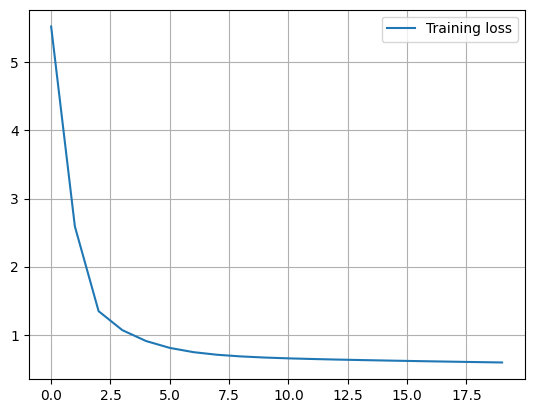

In [67]:
plt.plot(list_losses, label='Training loss')
plt.grid()
plt.legend()

#### Implementing Mini-batch GD

What type of gradient descent have you used so far?

Let's now try to implement Mini-batch gradient descent.

To do so, we need to use the `DataLoader` class which facilitate the loading of batches of data. To be able to use a `DataLoader`, we first need to wrap our dataset as a `TensorDataset` object (this provide the correct API to the `DataLoader` class).

In [27]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # Creates a DataLoader for loading batches of 32 random samples

Let's also use the GPU to train the model this time. To do so, we need to move the model tensors to GPU with the following instruction.

**Warning**: Do not forget to reinitialise your model parameter first by re-running the cell where you defined it.

In [28]:
model = set_model().to(device)

Let's now update our training loop to:
- Calculate the gradient update over a batch of data and not the full dataset.
- Use the GPU to perform the training.

Look at the lines with the #NEW tag and try to understand wht changed compared to the previous training loop.

In [29]:
def train_v3(model, optimizer, loss_fn, train_loader, n_epochs):
    losses = []
    model.train() # Puts the model in training mode, will be useful later on when we use other types of layers
    for epoch in range(n_epochs):
        epoch_loss = 0. # NEW
        for X_batch, y_batch in train_loader: # NEW
            X_batch, y_batch = X_batch.to(device), y_batch.to(device) # NEW
            y_pred = model(X_batch) # NEW
            loss = loss_fn(y_pred, y_batch)
            epoch_loss += loss.item() # NEW
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_epoch_loss = epoch_loss / len(train_loader) # NEW
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_epoch_loss:.4f}")
        losses.append(mean_epoch_loss)
    return losses

You can now train the model with the new training loop.

You can try to lower the learning rate by a factor 10 if the training does not converge.

In [32]:
model = set_model().to(device)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
list_losses = train_v3(model, optimizer, mse, train_loader, n_epochs)

Epoch 1/20, Loss: 0.9726
Epoch 2/20, Loss: 0.5249
Epoch 3/20, Loss: 0.4634
Epoch 4/20, Loss: 0.4290
Epoch 5/20, Loss: 0.4050
Epoch 6/20, Loss: 0.3953
Epoch 7/20, Loss: 0.3801
Epoch 8/20, Loss: 0.3740
Epoch 9/20, Loss: 0.3681
Epoch 10/20, Loss: 0.3583
Epoch 11/20, Loss: 0.3540
Epoch 12/20, Loss: 0.3486
Epoch 13/20, Loss: 0.3458
Epoch 14/20, Loss: 0.3410
Epoch 15/20, Loss: 0.3404
Epoch 16/20, Loss: 0.3349
Epoch 17/20, Loss: 0.3317
Epoch 18/20, Loss: 0.3281
Epoch 19/20, Loss: 0.3241
Epoch 20/20, Loss: 0.3236


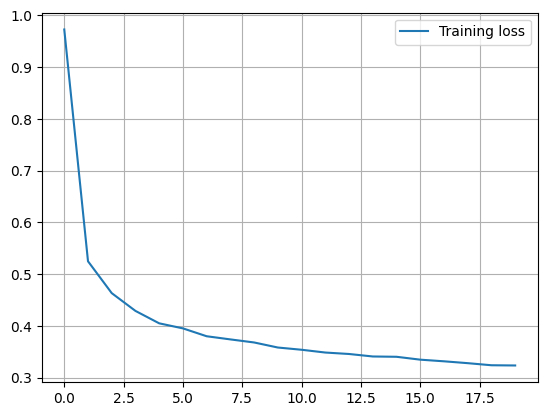

In [33]:
plt.plot(list_losses, label='Training loss')
plt.grid()
plt.legend()

We reached a lower loss than before, but each epoch took more time.

The lower loss can be explained by the fact that mini-batch GD introduces some stochatiscity in the optimisation process (i.e., it can help avoid local minima).

The higher time per update is explained by the fact that mini-batch GD makes several gradient update per epoch, while batch GD does only one. However, we reached a lower loss in with mini-batch GD in much less epochs than with batch GD.

## Coding time 3: Model evaluation

### Validation loss

It is usually good to also evaluate the model's loss on the validation set after each epoch, e.g., to monitor for overfitting.

Let's update our train function to include this.

In [34]:
def train_v4(model, optimizer, loss_fn, train_loader, valid_loader, n_epochs):
    train_losses = []
    valid_losses = []

    for epoch in range(n_epochs):
        #Training
        model.train()
        epoch_train_loss = 0.
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)
            y_train_pred = model(X_train_batch)
            train_loss = loss_fn(y_train_pred, y_train_batch)
            epoch_train_loss += train_loss.item()
            train_loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_epoch_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(mean_epoch_train_loss)

        # Validation
        model.eval()
        epoch_valid_loss = 0.
        with torch.no_grad():
            for X_valid_batch, y_valid_batch in valid_loader:
                X_valid_batch, y_valid_batch = X_valid_batch.to(device), y_valid_batch.to(device)
                y_valid_pred = model(X_valid_batch)
                valid_loss = loss_fn(y_valid_pred, y_valid_batch)
                epoch_valid_loss += valid_loss.item()
        mean_epoch_valid_loss = epoch_valid_loss / len(valid_loader)
        valid_losses.append(mean_epoch_valid_loss)

        print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {mean_epoch_train_loss:.4f}, Valid Loss: {mean_epoch_valid_loss:.4f}")

    return (train_losses, valid_losses)

In [35]:
valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

In [57]:
model = set_model().to(device)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
n_epochs = 20
train_losses, valid_losses = train_v4(model, optimizer, mse, train_loader, valid_loader, n_epochs)

NameError: name 'device' is not defined

In [ ]:
plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.grid()
plt.legend()

### Evaluation metrics and classification

Let's now train an image classifier and use evaluation metrics.  

`torchvision` is the PyTorch module containing popular datasets, model architectures, and common image transformations for computer vision. We will just use it to load the Fashion MNIST dataset and do a few quick pre-processing today.

In [54]:
import torchvision
import torchvision.transforms.v2 as T

The following instructions are used to:
1. Define a pre-processing function to convert images to PyTorch `Image` datatype (subclass of `Tensor`), with float32 type and scaling of the pixel's values between 0 and 1 (from 0 to 255 in original images).
2. Load the Fashion MNIST dataset (train and test sets) and apply the pre-processing.
3. Split the trainig data in training and validation sets.

In [56]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)]) # Define a pre-processing function to convert loaded images to adequate format
train_and_valid_data = torchvision.datasets.FashionMNIST(root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(root="datasets", train=False, download=True, transform=toTensor)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])

100%|█████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:09<00:00, 2.66MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 94.2kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:07<00:00, 570kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<?, ?B/s]


Create the data loaders.

In [57]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

Look at the shape of the first image, its data type and the target class name.

In [41]:
X_sample, y_sample = train_data[0]
X_sample.shape

torch.Size([1, 28, 28])

In [42]:
X_sample.dtype

torch.float32

In [43]:
train_and_valid_data.classes[y_sample]

'Pullover'

You can find below a more structured way of declaring a model. This can give you more freedom in terms of architecture design.

The code defines a class, inheriting from the `nn.Module` module, to instance models with 2 hidden layers and one output layer. The user can pass the number of inputs, neurons in hidden layer 1 and 2 and number of classes to instance models.

The `forward` method has to be present if you use this approach, as this is automatically called when you use perform a forward pass through the model (i.e., `model(X)`).

In [58]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
      super().__init__()
      self.mlp = nn.Sequential(
          nn.Flatten(),
          nn.Linear(n_inputs, n_hidden1),
          nn.ReLU(),
          nn.Linear(n_hidden1, n_hidden2),
          nn.ReLU(),
          nn.Linear(n_hidden2, n_classes)
      )
    def forward(self, X):
        return self.mlp(X)


Let's update our previous traninig loop to include the evaluation metric calculation and return.

In [59]:
def train_v5(model, optimizer, loss_fn, eval_metric, train_loader, valid_loader, n_epochs):
    train_losses = []
    train_eval_metrics = []
    valid_losses = []
    valid_eval_metrics= []

    for epoch in range(n_epochs):

        #Training
        eval_metric.reset() # Reset the eval metric
        model.train()
        epoch_train_loss = 0.
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)
            y_train_pred = model(X_train_batch)
            train_loss = loss_fn(y_train_pred, y_train_batch)
            epoch_train_loss += train_loss.item()
            train_loss.backward()
            eval_metric.update(y_train_pred, y_train_batch) # Update eval metric for training
            optimizer.step()
            optimizer.zero_grad()
        mean_epoch_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(mean_epoch_train_loss)
        # Calculte and store training eval metric for this epoch
        epoch_training_eval_metric = eval_metric.compute().item()
        train_eval_metrics.append(epoch_training_eval_metric)

        # Model evaluation
        model.eval()
        eval_metric.reset() # Reset the eval metric
        epoch_valid_loss = 0.
        with torch.no_grad():
            for X_valid_batch, y_valid_batch in valid_loader:
                X_valid_batch, y_valid_batch = X_valid_batch.to(device), y_valid_batch.to(device)
                y_valid_pred = model(X_valid_batch)
                valid_loss = loss_fn(y_valid_pred, y_valid_batch)
                epoch_valid_loss += valid_loss.item()  # Update eval metric for validation
                eval_metric.update(y_valid_pred, y_valid_batch)
        mean_epoch_valid_loss = epoch_valid_loss / len(valid_loader)
        valid_losses.append(mean_epoch_valid_loss)
        # Calculte and store validation eval metric for this epoch
        epoch_valid_eval_metric = eval_metric.compute().item()
        valid_eval_metrics.append(epoch_valid_eval_metric)

        print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {mean_epoch_train_loss:.4f}, Valid Loss: {mean_epoch_valid_loss:.4f}")
        print(f"Epoch {epoch + 1}/{n_epochs}, Training Eval Metric: {epoch_training_eval_metric:.4f}, Valid Eval Metric: {epoch_valid_eval_metric:.4f}")

    return (train_losses, valid_losses, train_eval_metrics, valid_eval_metrics)

Create an instance of the model and define the loss as Cross Entropy (loss for classification), the evaluation metric as accuracy, the optimiser as SGD (which works as mini-batch GD in our setup) and the number of epochs to 10.

Move the model to the GPU and start the training (will take a few minutes on the Colab T4 GPU).

In [64]:
model = ImageClassifier(n_inputs=28 * 28, n_hidden1=300, n_hidden2=100, n_classes=10)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
n_epochs = 20

model = model.to(device)
train_losses, valid_losses, train_accuracy, valid_accuracy = train_v5(model, optimizer, xentropy, accuracy, train_loader, valid_loader, n_epochs)

Epoch 1/20, Training Loss: 1.0931, Valid Loss: 0.6835
Epoch 1/20, Training Eval Metric: 0.6348, Valid Eval Metric: 0.7542
Epoch 2/20, Training Loss: 0.5975, Valid Loss: 0.5432
Epoch 2/20, Training Eval Metric: 0.7909, Valid Eval Metric: 0.8100
Epoch 3/20, Training Loss: 0.5106, Valid Loss: 0.4828
Epoch 3/20, Training Eval Metric: 0.8207, Valid Eval Metric: 0.8348
Epoch 4/20, Training Loss: 0.4691, Valid Loss: 0.4549
Epoch 4/20, Training Eval Metric: 0.8356, Valid Eval Metric: 0.8446
Epoch 5/20, Training Loss: 0.4452, Valid Loss: 0.4527
Epoch 5/20, Training Eval Metric: 0.8435, Valid Eval Metric: 0.8388
Epoch 6/20, Training Loss: 0.4259, Valid Loss: 0.4673
Epoch 6/20, Training Eval Metric: 0.8509, Valid Eval Metric: 0.8288
Epoch 7/20, Training Loss: 0.4114, Valid Loss: 0.4146
Epoch 7/20, Training Eval Metric: 0.8554, Valid Eval Metric: 0.8552
Epoch 8/20, Training Loss: 0.3976, Valid Loss: 0.4042
Epoch 8/20, Training Eval Metric: 0.8599, Valid Eval Metric: 0.8588
Epoch 9/20, Training Los

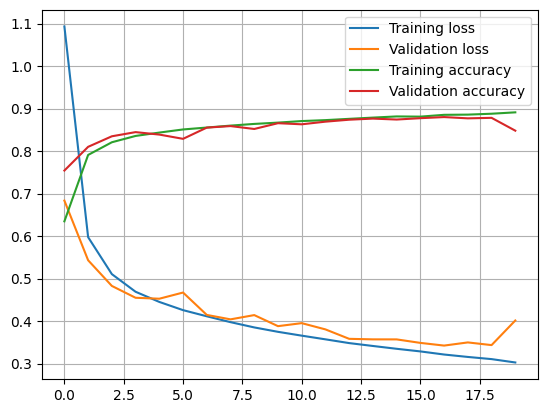

In [66]:
plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.plot(train_accuracy, label='Training accuracy')
plt.plot(valid_accuracy, label='Validation accuracy')
plt.grid()
plt.legend()

You can now use the model to make predictions on "new" images.

In [46]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
  y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(axis=1) # index of the largest logit
y_pred

RuntimeError: mat1 and mat2 shapes cannot be multiplied (84x28 and 8x50)

In [ ]:
[train_and_valid_data.classes[index] for index in y_pred]